# EDA + STATISTICS 

## Import Libraries

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats


## Load Dataset

In [6]:
df = pd.read_csv("Customer_support_data_cleaned.csv")
df.head()


,unique_id,channel_name,category,sub-category,customer_remarks,order_id,order_date_time,issue_reported_at,issue_responded,survey_response_date,customer_city,product_category,item_price,connected_handling_time,agent_name,supervisor,manager,tenure_bucket,agent_shift,csat_score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,Unknown,c27c9bb4-fa36-4140-9f1f-21009254ffdb,Unknown,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,Unknown,Unknown,979.0,427.0,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,Unknown,d406b0c7-ce17-4654-b9de-f08d421254bd,Unknown,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,Unknown,Unknown,979.0,427.0,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,Unknown,c273368d-b961-44cb-beaf-62d6fd6c00d5,Unknown,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,Unknown,Unknown,979.0,427.0,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,Unknown,5aed0059-55a4-4ec6-bb54-97942092020a,Unknown,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,Unknown,Unknown,979.0,427.0,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,Unknown,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,Unknown,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,Unknown,Unknown,979.0,427.0,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


## Basic Data Understanding

In [7]:
df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   unique_id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   sub-category             85907 non-null  object 
 4   customer_remarks         85907 non-null  object 
 5   order_id                 85907 non-null  object 
 6   order_date_time          85907 non-null  object 
 7   issue_reported_at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   survey_response_date     85907 non-null  object 
 10  customer_city            85907 non-null  object 
 11  product_category         85907 non-null  object 
 12  item_price               85907 non-null  float64
 13  connected_handling_time  85907 non-null  float64
 14  agent_name            

,item_price,connected_handling_time,csat_score
count,85907.000000,85907.000000,85907.000000
mean,1916.695624,427.099724,4.242157
std,6037.903897,13.179491,1.378903
min,0.000000,0.000000,1.000000
25%,979.000000,427.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,979.000000,427.000000,5.000000
max,164999.000000,1986.000000,5.000000


## Missing Values Check

In [8]:
df.isnull().sum()


unique_id                  0
channel_name               0
category                   0
sub-category               0
customer_remarks           0
order_id                   0
order_date_time            0
issue_reported_at          0
issue_responded            0
survey_response_date       0
customer_city              0
product_category           0
item_price                 0
connected_handling_time    0
agent_name                 0
supervisor                 0
manager                    0
tenure_bucket              0
agent_shift                0
csat_score                 0
dtype: int64

## CSAT Score Distribution 

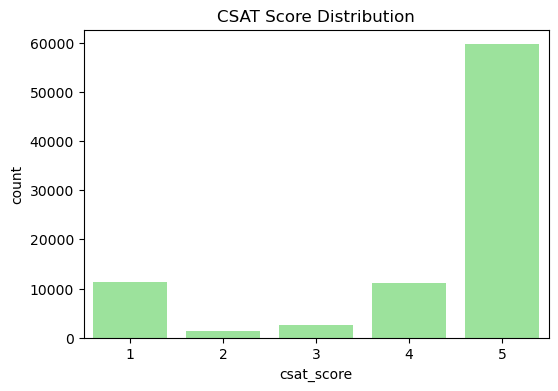

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='csat_score', data=df , color='lightgreen')
plt.title("CSAT Score Distribution")
plt.show()


Most customers give a CSAT score of 5, indicating overall high satisfaction with customer support.

Scores 1 and 4 appear in noticeable numbers, showing some customers are either very unhappy or moderately satisfied.

Scores 2 and 3 are very low, meaning neutral or slightly dissatisfied customers are fewer.

The distribution is highly imbalanced, which is important to consider while building ML models.

## CSAT vs Category

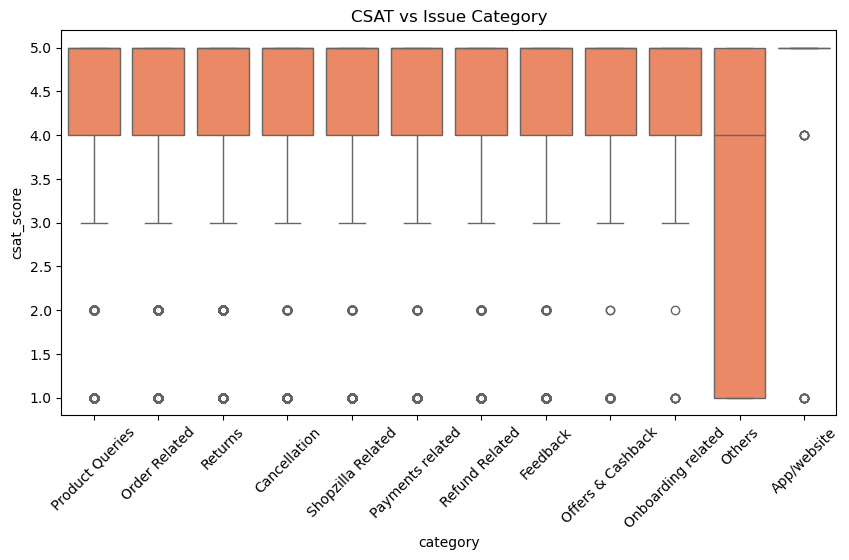

In [15]:
plt.figure(figsize=(10,5))
sns.boxplot(x='category', y='csat_score', data=df, color= 'coral')
plt.xticks(rotation=45)
plt.title("CSAT vs Issue Category")
plt.show()


Most issue categories have high CSAT scores (4–5), showing customers are generally satisfied across services.

Product Queries, Orders, Returns, and Payments show similar satisfaction levels, indicating consistent support quality.

“Others” category shows wide variation, including low CSAT scores, which means mixed or unclear issues reduce satisfaction.

App/Website issues have fewer complaints but include low ratings, suggesting technical problems impact customer experience more.

## Handling Time Distribution

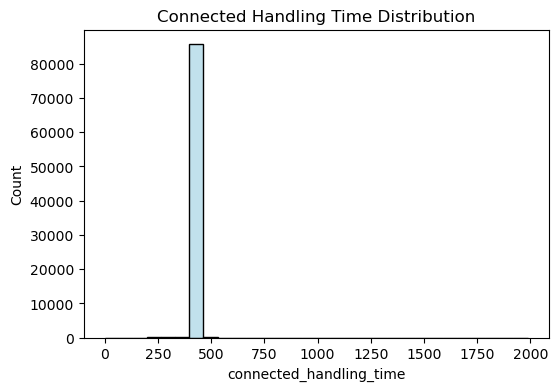

In [18]:
plt.figure(figsize=(6,4))
sns.histplot(df['connected_handling_time'], bins=30, color='lightblue')
plt.title("Connected Handling Time Distribution")
plt.show()


Most customer issues are resolved within a short handling time, showing efficient support operations.

The distribution is right-skewed, meaning a small number of cases take very long time to resolve.

Very high handling times are rare, but they indicate complex or problematic issues.

These long-duration cases should be analyzed separately to improve overall service efficiency.

## CSAT vs Handling Time

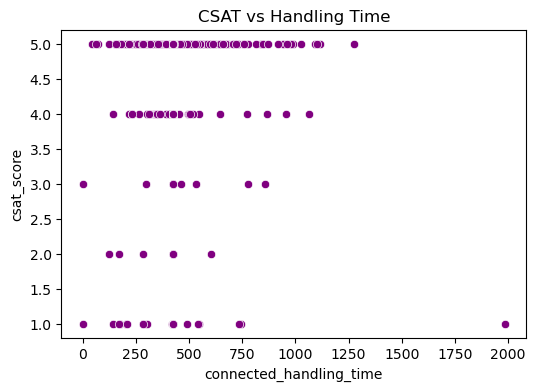

In [21]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='connected_handling_time', y='csat_score', data=df, color='purple')
plt.title("CSAT vs Handling Time")
plt.show()


High CSAT scores (4–5) occur mostly at lower handling times, indicating quick resolution improves satisfaction.

As handling time increases, CSAT scores become more spread out, including more low ratings.

Very long handling times are associated with poor CSAT, showing customer frustration for delayed resolution.

Overall, handling time has a negative relationship with CSAT, but it is not the strongest factor.

## CSAT vs Agent Tenure

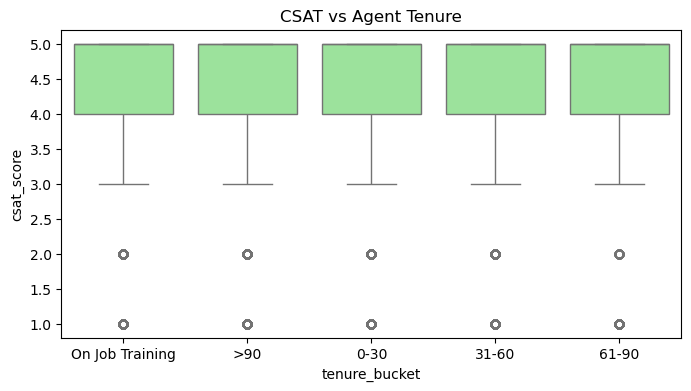

In [22]:
plt.figure(figsize=(8,4))
sns.boxplot(x='tenure_bucket', y='csat_score', data=df, color="lightgreen")
plt.title("CSAT vs Agent Tenure")
plt.show()


Customer satisfaction is generally high (4–5) across all tenure groups, showing consistent service quality.

Experienced agents (61–90 and >90 days) show slightly more stable CSAT scores with fewer low ratings.

New agents (On Job Training and 0–30 days) have more low-score outliers, indicating learning-phase challenges.

Agent experience positively influences CSAT, but training helps maintain good performance across all levels.

## Correlation Analysis

In [23]:
df[['connected_handling_time','csat_score']].corr()


,connected_handling_time,csat_score
connected_handling_time,1.000000,0.003392
csat_score,0.003392,1.000000


The correlation between handling time and CSAT score is very close to zero (~0.003).

This shows handling time has almost no direct linear relationship with customer satisfaction.

Longer or shorter calls alone do not strongly affect CSAT.

Customer satisfaction depends more on issue type and service quality, not just time spent.

## Hypothesis Testing (T-Test) 

In [24]:
short_time = df[df['connected_handling_time'] < 300]['csat_score']
long_time = df[df['connected_handling_time'] > 600]['csat_score']

stats.ttest_ind(short_time, long_time)


TtestResult(statistic=np.float64(-1.64066003834364), pvalue=np.float64(0.10350863137145873), df=np.float64(119.0))

The p-value is 0.103, which is greater than 0.05, so the result is not statistically significant.

This means there is no strong evidence that long handling time reduces customer satisfaction.

The difference in average CSAT between short calls (<300s) and long calls (>600s) is not meaningful.

Customer satisfaction depends more on issue resolution quality and category, not just call duration. 

--- Handling time alone does not significantly impact customer satisfaction 

# MACHINE LEARNING 

## Import ML Libraries

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


## Feature Selection

In [26]:
X = df[['channel_name',
        'category',
        'tenure_bucket',
        'agent_shift',
        'connected_handling_time']]

y = df['csat_score']


The selected features represent how customers contact support, what issue they face, and who handles it.

Issue category is included because it strongly influences customer satisfaction.

Agent-related features (tenure and shift) help measure service quality and experience level.

Handling time is included to check if resolution duration affects CSAT, even though its impact is lower.

We selected features that capture customer behavior, issue type, and agent performance to predict CSAT.

## Encode Categorical Variables 

In [27]:
le = LabelEncoder()

for col in X.columns:
    X[col] = le.fit_transform(X[col])


C:\Users\Raksha Shetty\AppData\Local\Temp\ipykernel_22548\3768463402.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\Raksha Shetty\AppData\Local\Temp\ipykernel_22548\3768463402.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\Raksha Shetty\AppData\Local\Temp\ipykernel_22548\3768463402.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_inde

Categorical features are converted into numeric values so machine learning models can process them.

Label Encoding is suitable for tree-based models like Random Forest used in this project.

The warning does not affect results; it only indicates how pandas handles data copying.

Encoding ensures all features are in a usable format for model training and prediction.

We encoded categorical variables into numbers so the machine learning model can understand them

## Train-Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


So now split the data to train the model and then test its performance on new data

## Logistic Regression Model

In [29]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


D:\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.694564078686998
              precision    recall  f1-score   support

           1       0.00      0.00      0.00      2241
           2       0.00      0.00      0.00       227
           3       0.00      0.00      0.00       503
           4       0.00      0.00      0.00      2277
           5       0.69      1.00      0.82     11934

    accuracy                           0.69     17182
   macro avg       0.14      0.20      0.16     17182
weighted avg       0.48      0.69      0.57     17182



D:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The model achieved an accuracy of ~69.5%, which looks acceptable at first glance.

However, the model predicts almost all cases as CSAT = 5, because this class dominates the dataset.

Very poor performance for CSAT scores 1–4 (precision and recall are near zero).

This shows class imbalance and that Logistic Regression struggles with this dataset.

## Random Forest Model

In [31]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


In [32]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.6931672680712373
[[    5     0     0     5  2231]
 [    0     0     0     1   226]
 [    0     0     0     0   503]
 [    5     0     0     0  2272]
 [   16     0     1    12 11905]]
              precision    recall  f1-score   support

           1       0.19      0.00      0.00      2241
           2       0.00      0.00      0.00       227
           3       0.00      0.00      0.00       503
           4       0.00      0.00      0.00      2277
           5       0.69      1.00      0.82     11934

    accuracy                           0.69     17182
   macro avg       0.18      0.20      0.16     17182
weighted avg       0.51      0.69      0.57     17182



D:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The Random Forest model achieved an accuracy of ~69.3%, which is similar to Logistic Regression.

The model predicts CSAT score = 5 very well, with high recall (1.00) and strong F1-score.

Low CSAT classes (1–4) are still poorly predicted, mainly due to class imbalance in the dataset.

Compared to Logistic Regression, Random Forest handles feature interactions better and is more robust.

## Feature Importance

In [33]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)


category                   0.424598
tenure_bucket              0.208095
agent_shift                0.150025
channel_name               0.123657
connected_handling_time    0.093624
dtype: float64

Customer satisfaction is mainly driven by issue type and agent experience, not just how long the call lasts.

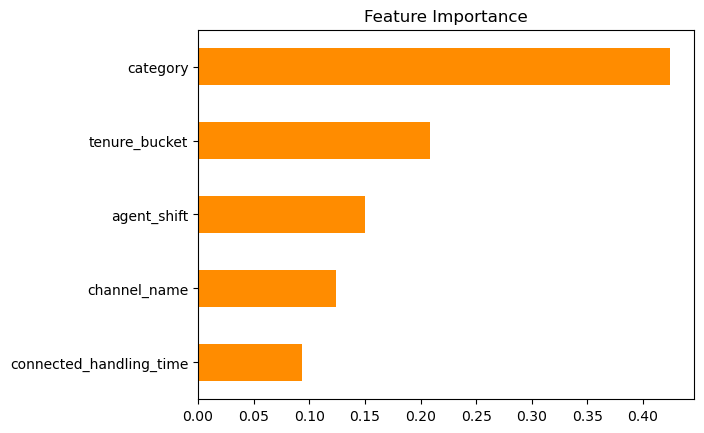

In [37]:

importance.sort_values().plot(
    kind='barh',
    title="Feature Importance",
    color='darkorange'
)
plt.show()


Issue category has the highest impact on customer satisfaction.

Agent experience (tenure) significantly influences CSAT scores.

Agent shift and support channel have a moderate effect on service quality.

Handling time has the least impact, showing quality matters more than duration.

## END 